<a href="https://colab.research.google.com/github/Poonam4385/Deep-learning/blob/main/Agricultural_crops_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Import requie lab
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
#  Check you dataset
base_data_dir = "/content/Agricultural-crops"

In [17]:
import os
print("Dataset path exists:", os.path.exists(base_data_dir))

if os.path.exists(base_data_dir):
    class_names = sorted(os.listdir(base_data_dir))

    print("Number of classes:", len(class_names))
    print("\nClasses:")

    for i, name in enumerate(class_names):
        print(i, name)

Dataset path exists: True
Number of classes: 30

Classes:
0 Cherry
1 Coffee-plant
2 Cucumber
3 Fox_nut(Makhana)
4 Lemon
5 Olive-tree
6 Pearl_millet(bajra)
7 Tobacco-plant
8 almond
9 banana
10 cardamom
11 chilli
12 clove
13 coconut
14 cotton
15 gram
16 jowar
17 jute
18 maize
19 mustard-oil
20 papaya
21 pineapple
22 rice
23 soyabean
24 sugarcane
25 sunflower
26 tea
27 tomato
28 vigna-radiati(Mung)
29 wheat


In [18]:
# count images in each class
image_counts = {}

for class_name in class_names:

    class_path = os.path.join(base_data_dir, class_name)

    if os.path.isdir(class_path):

        count = len([
            file for file in os.listdir(class_path)
            if file.lower().endswith(
                (".jpg", ".jpeg", ".png")
            )
        ])

        image_counts[class_name] = count


for class_name, count in image_counts.items():
    print(f"{class_name:25s}: {count}")

print("\nTotal images:", sum(image_counts.values()))

Cherry                   : 32
Coffee-plant             : 29
Cucumber                 : 31
Fox_nut(Makhana)         : 23
Lemon                    : 28
Olive-tree               : 30
Pearl_millet(bajra)      : 39
Tobacco-plant            : 33
almond                   : 21
banana                   : 31
cardamom                 : 22
chilli                   : 23
clove                    : 30
coconut                  : 25
cotton                   : 32
gram                     : 25
jowar                    : 30
jute                     : 23
maize                    : 31
mustard-oil              : 28
papaya                   : 23
pineapple                : 25
rice                     : 29
soyabean                 : 30
sugarcane                : 25
sunflower                : 24
tea                      : 23
tomato                   : 26
vigna-radiati(Mung)      : 27
wheat                    : 31

Total images: 829


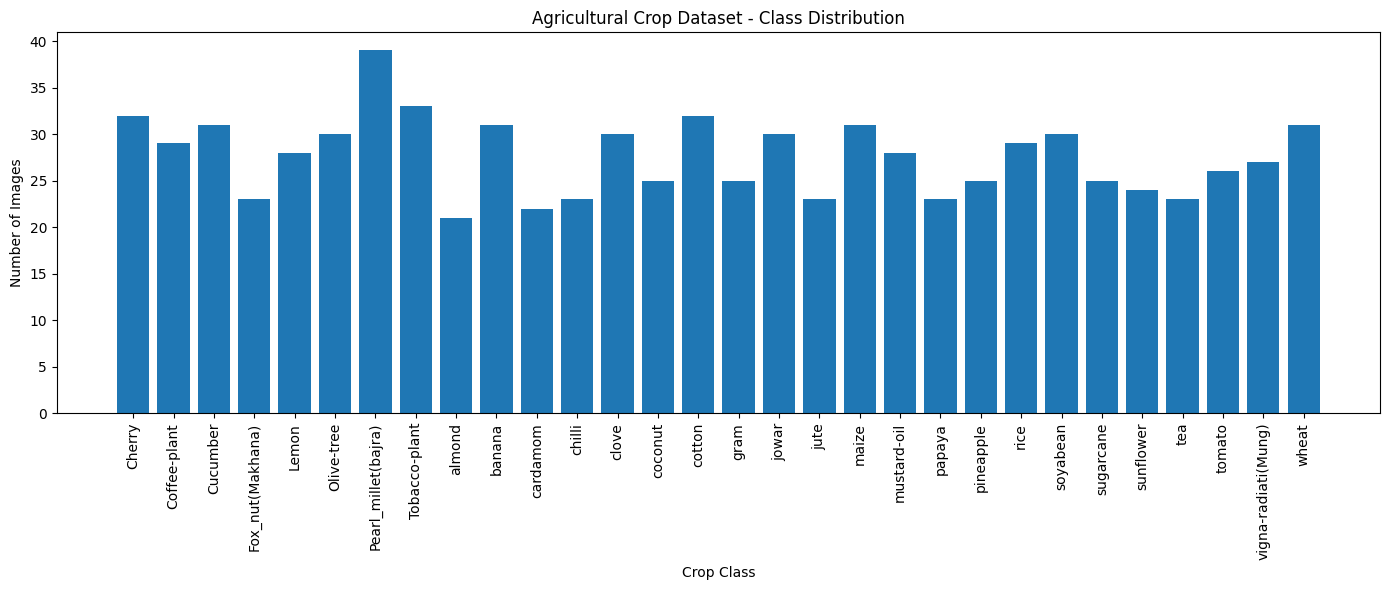

In [19]:
# visualize the distribution
plt.figure(figsize=(14, 6))

plt.bar(
    image_counts.keys(),
    image_counts.values()
)

plt.xticks(rotation=90)

plt.xlabel("Crop Class")
plt.ylabel("Number of Images")
plt.title("Agricultural Crop Dataset - Class Distribution")

plt.tight_layout()
plt.show()


In [21]:
# create the split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

In [22]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

In [23]:
train_data_gen = train_datagen.flow_from_directory(
    base_data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

validation_data_gen = validation_datagen.flow_from_directory(
    base_data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

Found 674 images belonging to 30 classes.
Found 155 images belonging to 30 classes.


In [24]:
# Check one batch
images, labels = next(train_data_gen)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 30)


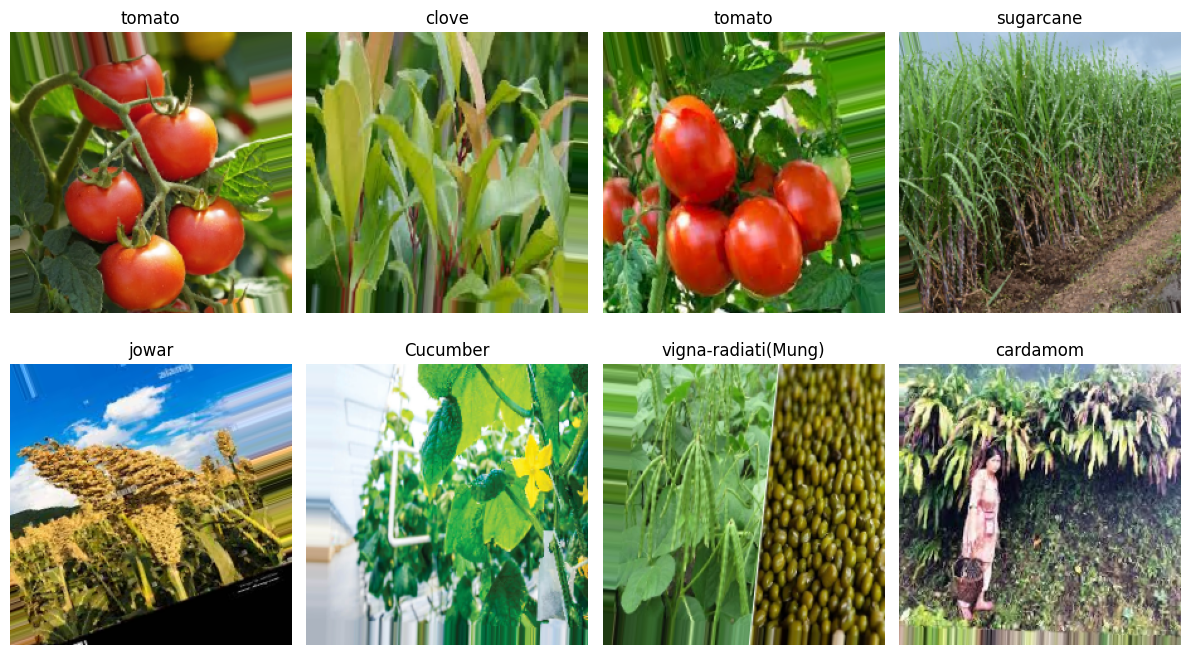

In [25]:
class_names = list(train_data_gen.class_indices.keys())

plt.figure(figsize=(12, 7))

for i in range(8):
    plt.subplot(2, 4, i + 1)

    plt.imshow(images[i])

    class_index = np.argmax(labels[i])
    class_name = class_names[class_index]

    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
# Build CNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input,Conv2D,MaxPooling2D,Dropout,Flatten,Dense)

model = Sequential([

    # Input layer
    Input(shape=(224, 224, 3)),

    # Convolution Block 1
    Conv2D(
        16,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # Convolution Block 2
    Conv2D(
        32,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # Convolution Block 3
    Conv2D(
        64,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # Classification
    Flatten(),

    Dense(
        512,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        30,
        activation='softmax'
    )
])

In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │        15,390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,729,598 (98.15 MB)

 Trainable params: 25,729,598 (98.15 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
Input(shape=(224, 224, 3))

<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_42>

In [32]:
# Compile the model
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
# Add callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

In [36]:
# Train
history = model.fit(
    train_data_gen,
    validation_data=validation_data_gen,
    epochs=30,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 573ms/step - accuracy: 0.3620 - loss: 2.1561 - val_accuracy: 0.2774 - val_loss: 2.6069 - learning_rate: 5.0000e-04
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 535ms/step - accuracy: 0.3754 - loss: 2.0946 - val_accuracy: 0.2516 - val_loss: 2.6362 - learning_rate: 5.0000e-04
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 546ms/step - accuracy: 0.3605 - loss: 2.1052 - val_accuracy: 0.2903 - val_loss: 2.5887 - learning_rate: 5.0000e-04
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 603ms/step - accuracy: 0.3798 - loss: 2.0564 - val_accuracy: 0.2387 - val_loss: 2.7018 - learning_rate: 5.0000e-04
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 549ms/step - accuracy: 0.4050 - loss: 1.9913 - val_accuracy: 0.2903 - val_loss: 2.6131 - learning_rate: 5.0000e-04
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 602ms/step - accuracy: 0.4006 - loss: 1.9663 - val_accuracy: 0.2903 - val_loss: 2.5579 - learning_rate: 5.0000e-04
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 556ms/step - acc

In [38]:
restore_best_weights=True

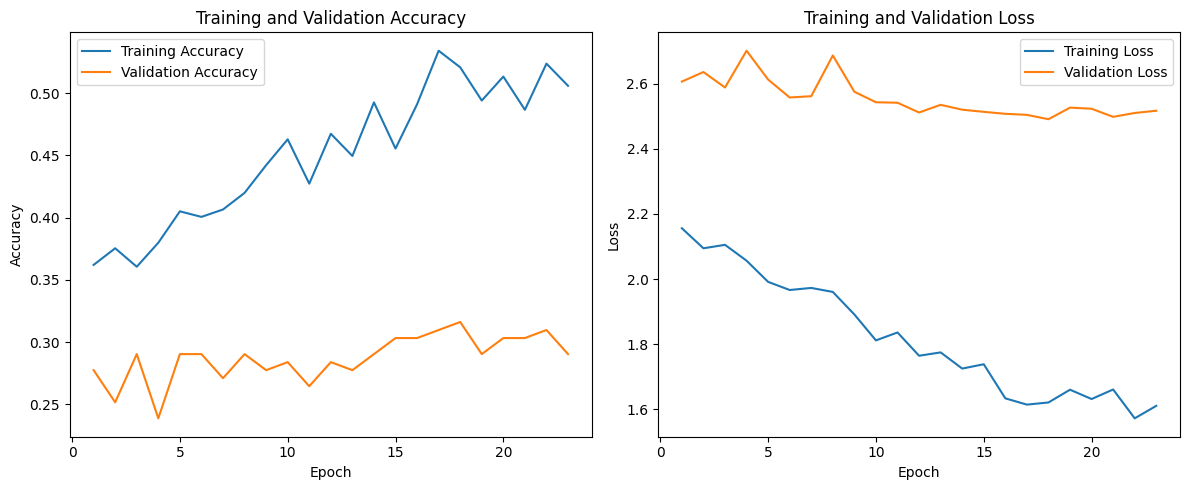

In [41]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)

plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()


# Loss
plt.subplot(1, 2, 2)

plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [42]:
val_loss, val_accuracy = model.evaluate(
    validation_data_gen
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 305ms/step - accuracy: 0.3161 - loss: 2.4912
Validation Loss: 2.4912
Validation Accuracy: 31.61%


In [43]:
# Save the model
model.save('model.h5')

print("Model saved successfully!")

Model saved successfully!


In [45]:
# Step 12: Prediction and Testing

path = "/content/Tomato.jpg"

from keras.models import load_model
import cv2
import numpy as np

model = load_model('model.h5')

img = cv2.imread(path)
img = cv2.resize(img, (224, 224))

y_hat = model.predict(np.expand_dims(img, axis=0))

if y_hat[0][0] > 0.5:
    print("Tomato")

else:
    print("No")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 731ms/step
Tomato
